# Bookstore Analytics — DuckDB Portfolio Project

This notebook connects to `bookstore.duckdb` and runs **25 analytical queries** across three complexity tiers:

| Tier | Count |
|------|-------|
| Basic | 5 |
| Intermediate | 15 |
| Advanced | 5 |

Each cell includes: **what we are doing**, the **SQL query**, the **result**, and a **plot** when applicable.

> Plotting code is decoupled into `plot_helpers.py`.

## Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from plot_helpers import (
    bar_chart, pie_chart, line_chart, grouped_bar_chart,
    stacked_bar_chart, histogram, scatter_plot, heatmap, multi_line_chart,
    PALETTE
)
%matplotlib inline

con = duckdb.connect("bookstore.duckdb", read_only=True)

# Quick sanity check
for t in ["books", "customers", "orders"]:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:>12s}: {n:>7,} rows")

       books:     503 rows
   customers:     504 rows
      orders:   7,500 rows


---
## Basic Queries

### B1 — Count of Books by Genre
How many books do we carry in each genre?

In [2]:
sql = """
SELECT genre,
       COUNT(*) AS book_count
FROM   books
GROUP  BY genre
ORDER  BY book_count DESC;
"""
df = con.execute(sql).df()
df

,genre,book_count
0,Science Fiction,86
1,Mystery,80
2,Romance,74
3,Fantasy,71
4,Non-Fiction,67
5,Biography,65
6,Fiction,60


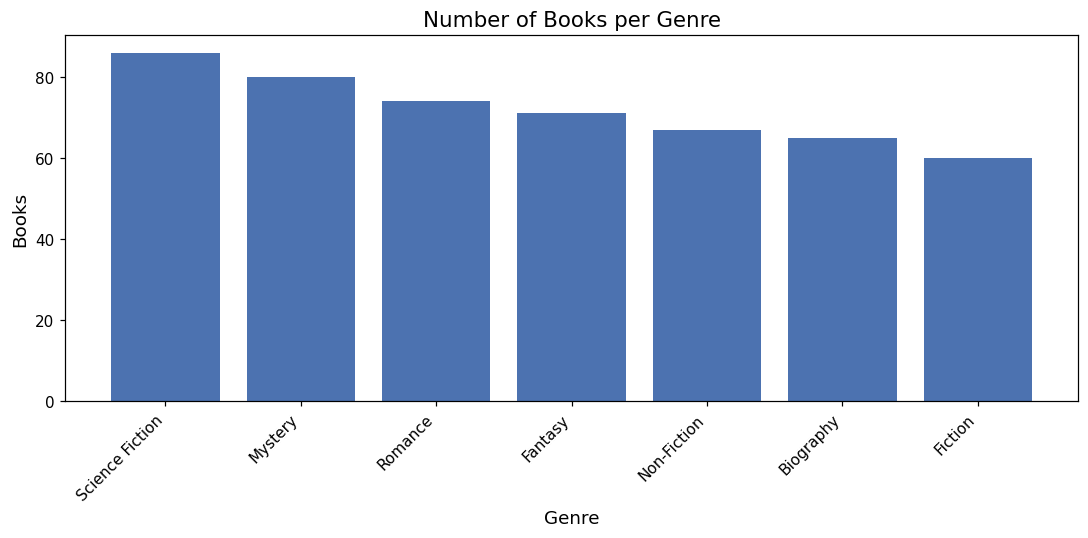

In [3]:
bar_chart(df, "genre", "book_count",
          "Number of Books per Genre",
          xlabel="Genre", ylabel="Books")
plt.show()

### B2 — Average Book Price
What is the overall average price of books in the store?

In [4]:
sql = """
SELECT ROUND(AVG(price), 2) AS avg_price,
       ROUND(MIN(price), 2) AS min_price,
       ROUND(MAX(price), 2) AS max_price
FROM   books;
"""
df = con.execute(sql).df()
df

,avg_price,min_price,max_price
0,27.44,5.07,55.46


### B3 — Top 10 Most Recently Published Books
Which 10 books were published most recently?

In [5]:
sql = """
SELECT title, author, genre, published_year, price
FROM   books
ORDER  BY published_year DESC
LIMIT  10;
"""
df = con.execute(sql).df()
df

,title,author,genre,published_year,price
0,Team-oriented empowering synergy,Sandra Williams,Non-Fiction,2023,35.06
1,Visionary optimizing project,Douglas Bush,Biography,2022,46.30
2,Pre-emptive asynchronous leverage,Courtney Nichols,Fantasy,2022,16.47
3,Sharable regional product,Michael Walker,Biography,2022,8.94
4,Triple-buffered upward-trending artificial int...,John Shannon,Biography,2021,32.82
5,Adaptive 4thgeneration concept,Hector Palmer,Non-Fiction,2021,39.47
6,Upgradable interactive emulation,Christopher Ross,Biography,2021,28.12
7,Reduced well-modulated database,Raymond Nicholson,Non-Fiction,2021,47.92
8,Synergistic dedicated concept,Lisa Bailey,Mystery,2021,21.56
9,Customer-focused context-sensitive process imp...,Mary Warren,Science Fiction,2021,23.45


### B4 — Customers per Country (Top 15)
Which countries have the most customers?

In [6]:
sql = """
SELECT country,
       COUNT(*) AS total_customers
FROM   customers
GROUP  BY country
ORDER  BY total_customers DESC
LIMIT  15;
"""
df = con.execute(sql).df()
df

,country,total_customers
0,Cuba,7
1,Zimbabwe,6
2,Micronesia,6
3,Senegal,5
4,Heard Island and McDonald Islands,5
5,Saint Kitts and Nevis,5
6,Armenia,5
7,Tokelau,5
8,Turkey,5
9,Slovakia (Slovak Republic),5


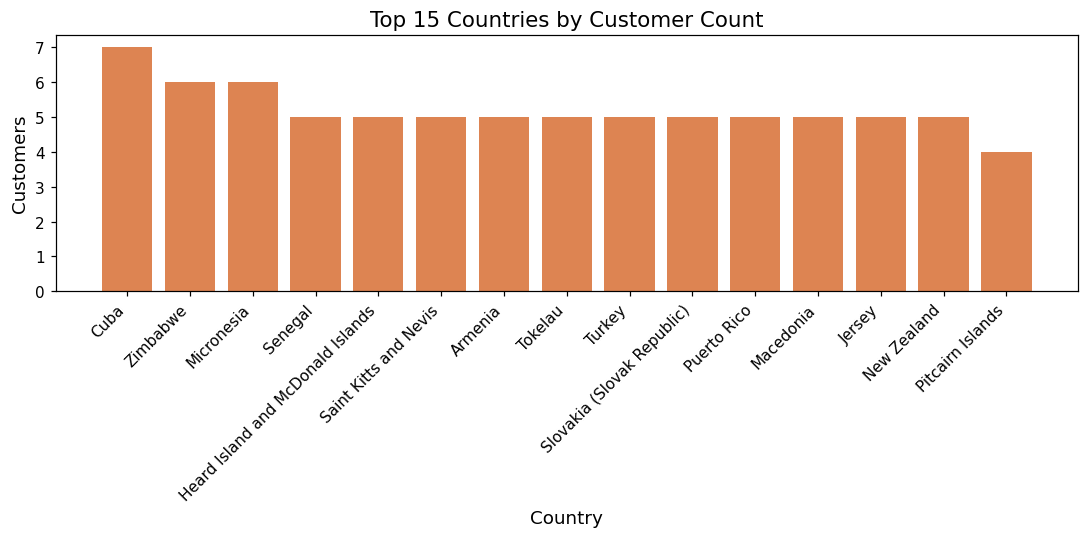

In [7]:
bar_chart(df, "country", "total_customers",
          "Top 15 Countries by Customer Count",
          xlabel="Country", ylabel="Customers",
          color=PALETTE[1])
plt.show()

### B5 — Total Revenue
What is the total revenue generated from all orders?

In [8]:
sql = """
SELECT ROUND(SUM(total_amount), 2)  AS total_revenue,
       COUNT(*)                      AS total_orders,
       ROUND(AVG(total_amount), 2)  AS avg_order_value
FROM   orders;
"""
df = con.execute(sql).df()
df

,total_revenue,total_orders,avg_order_value
0,633859.19,7500,84.51


---
## Intermediate Queries

### I1 — Monthly Revenue Trend
How does revenue change month over month?

In [9]:
sql = """
SELECT STRFTIME(order_date, '%Y-%m') AS month,
       ROUND(SUM(total_amount), 2)   AS revenue,
       COUNT(*)                       AS orders
FROM   orders
GROUP  BY month
ORDER  BY month;
"""
df = con.execute(sql).df()
df.tail(12)

,month,revenue,orders
25,2025-01,15793.13,192
26,2025-02,16779.52,192
27,2025-03,19912.73,249
28,2025-04,19920.93,241
29,2025-05,23256.67,283
30,2025-06,23030.06,278
31,2025-07,28298.44,355
32,2025-08,20412.84,263
33,2025-09,23528.10,278
34,2025-10,26541.73,321


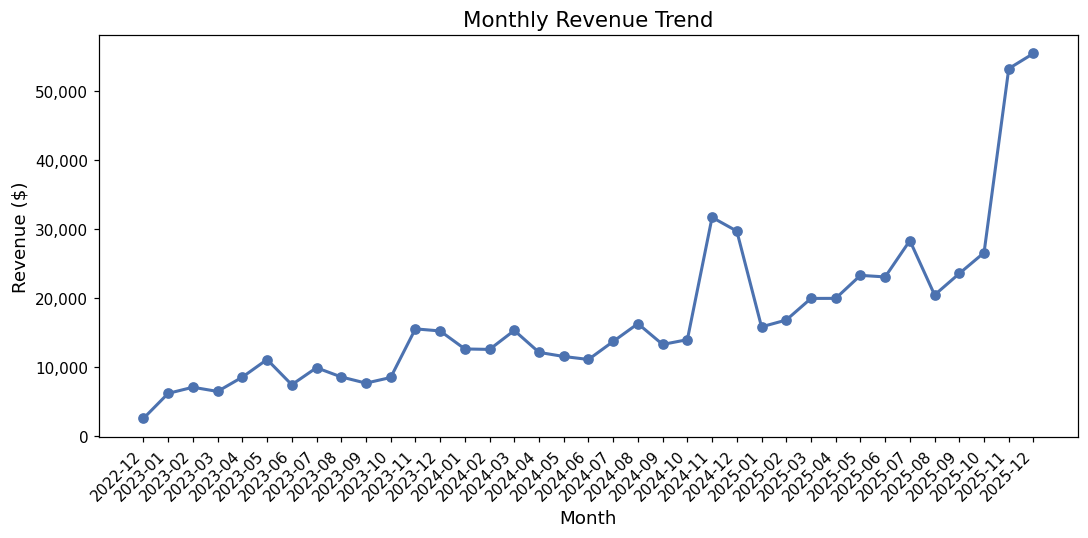

In [10]:
line_chart(df, "month", "revenue",
           "Monthly Revenue Trend",
           xlabel="Month", ylabel="Revenue ($)")
plt.show()

### I2 — Revenue by Genre
Which genres generate the most revenue?

In [11]:
sql = """
SELECT b.genre,
       ROUND(SUM(o.total_amount), 2) AS revenue,
       SUM(o.quantity)                AS units_sold
FROM   orders o
JOIN   books b ON o.book_id = b.book_id
GROUP  BY b.genre
ORDER  BY revenue DESC;
"""
df = con.execute(sql).df()
df

,genre,revenue,units_sold
0,Science Fiction,102448.65,3795.0
1,Mystery,96456.56,3652.0
2,Romance,94760.96,3412.0
3,Non-Fiction,88564.96,3047.0
4,Fantasy,88375.10,3374.0
5,Biography,85518.37,3056.0
6,Fiction,77734.59,2684.0


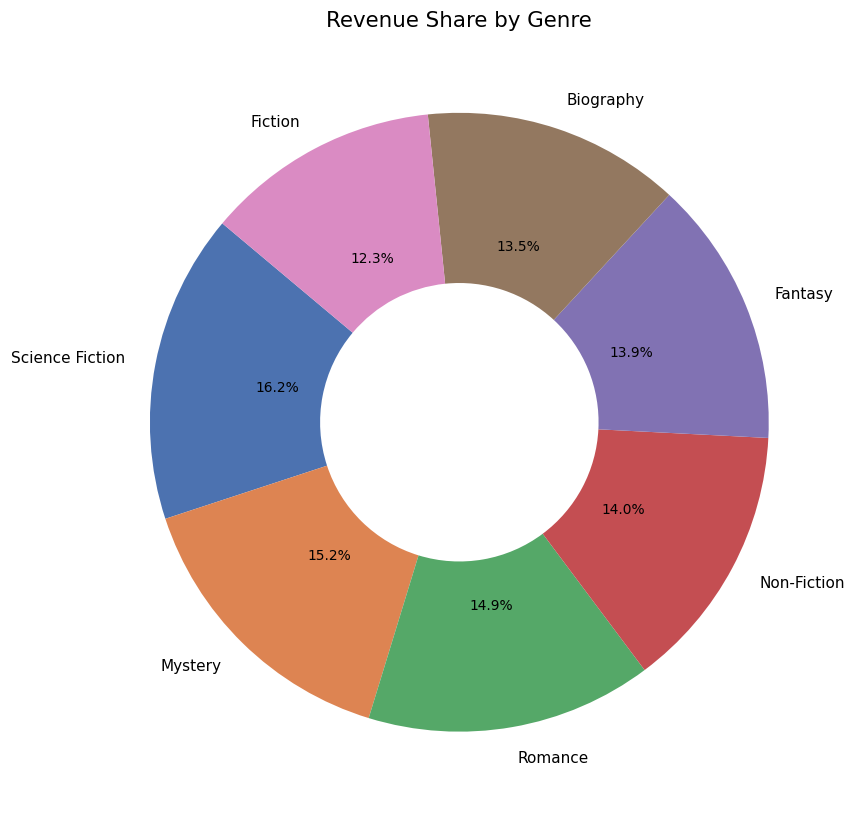

In [12]:
pie_chart(df, "genre", "revenue",
          "Revenue Share by Genre")
plt.show()

### I3 — Top 10 Best-Selling Books (by Quantity)
Which individual titles sold the most copies?

In [13]:
sql = """
SELECT b.title,
       b.author,
       SUM(o.quantity)                AS total_qty,
       ROUND(SUM(o.total_amount), 2) AS total_rev
FROM   orders o
JOIN   books b ON o.book_id = b.book_id
GROUP  BY b.title, b.author
ORDER  BY total_qty DESC
LIMIT  10;
"""
df = con.execute(sql).df()
df

,title,author,total_qty,total_rev
0,Organized even-keeled conglomeration,Christopher Ray,93.0,2593.77
1,Grass-roots systematic moderator,Joyce Patton,92.0,4223.72
2,Reverse-engineered directional conglomeration,John Christian,87.0,1772.19
3,Monitored interactive focus group,Thomas Chung,86.0,3814.96
4,Realigned multi-tasking installation,Patrick Contreras,84.0,1783.32
5,Team-oriented tangible ability,Veronica Hebert,83.0,3679.39
6,Optional clear-thinking task-force,Samuel Morales,82.0,3457.94
7,Integrated exuding application,Elizabeth Morrison,81.0,2253.42
8,Advanced didactic time-frame,Thomas Trujillo,81.0,1552.77
9,Networked contextually-based throughput,Andrea Eaton,80.0,3723.20


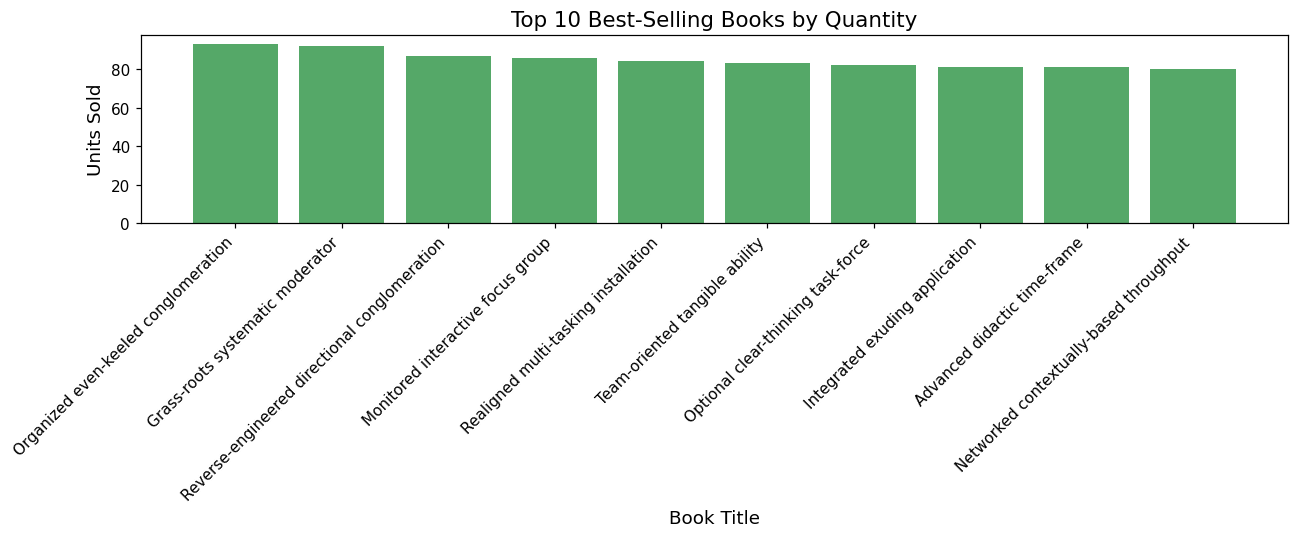

In [14]:
bar_chart(df, "title", "total_qty",
          "Top 10 Best-Selling Books by Quantity",
          xlabel="Book Title", ylabel="Units Sold",
          color=PALETTE[2], figsize=(12, 5))
plt.show()

### I4 — Top 10 Customers by Total Spend
Who are our highest-value customers?

In [15]:
sql = """
SELECT c.customer_id,
       c.name,
       c.country,
       COUNT(o.order_id)              AS order_count,
       ROUND(SUM(o.total_amount), 2) AS total_spent
FROM   orders o
JOIN   customers c ON o.customer_id = c.customer_id
GROUP  BY c.customer_id, c.name, c.country
ORDER  BY total_spent DESC
LIMIT  10;
"""
df = con.execute(sql).df()
df

,customer_id,name,country,order_count,total_spent
0,115,Jacob Fernandez,Micronesia,127,11457.05
1,13,Kristine Kim,Nigeria,131,11299.67
2,303,Jose Lee,Iran,125,10910.73
3,45,Jennifer Fowler,Ireland,135,10715.71
4,141,Ryan Hernandez,Saint Pierre and Miquelon,119,10565.33
5,378,Anthony Kane,Congo,124,10465.80
6,58,Michael Young,United Arab Emirates,127,10343.26
7,347,Peter Greene,Sri Lanka,146,10256.92
8,457,Kim Turner,Cambodia,121,10243.01
9,126,Bonnie Mcdonald,Myanmar,123,10081.90


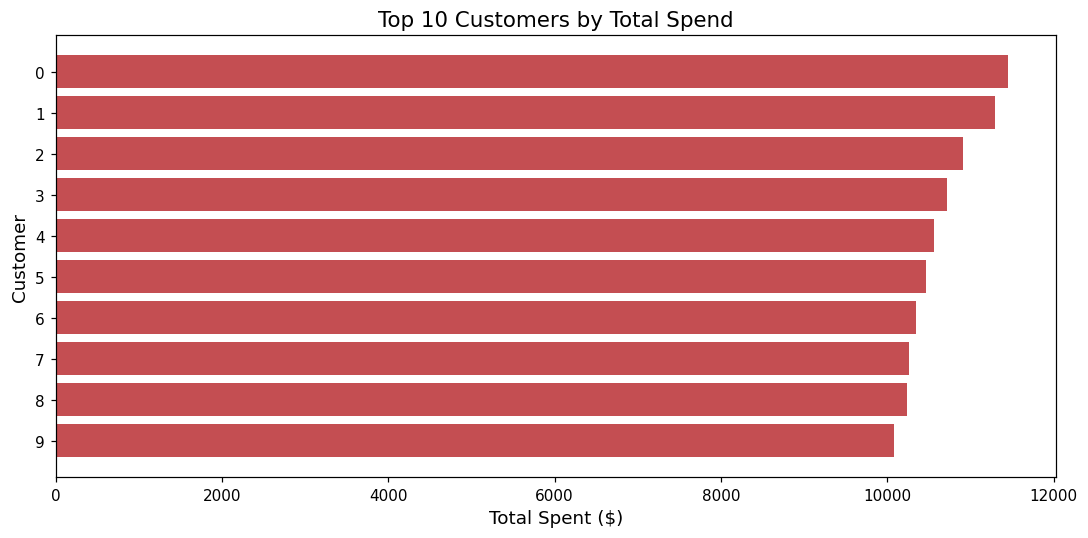

In [16]:
bar_chart(df, "name", "total_spent",
          "Top 10 Customers by Total Spend",
          xlabel="Customer", ylabel="Total Spent ($)",
          horizontal=True, color=PALETTE[3])
plt.show()

### I5 — Year-over-Year Revenue
How does annual revenue compare across years?

In [17]:
sql = """
SELECT EXTRACT(YEAR FROM order_date) AS year,
       ROUND(SUM(total_amount), 2)   AS revenue,
       COUNT(*)                       AS orders,
       ROUND(AVG(total_amount), 2)   AS avg_order
FROM   orders
GROUP  BY year
ORDER  BY year;
"""
df = con.execute(sql).df()
df

,year,revenue,orders,avg_order
0,2022,2513.36,16,157.08
1,2023,111736.69,1256,88.96
2,2024,193468.18,2228,86.83
3,2025,326140.96,4000,81.54


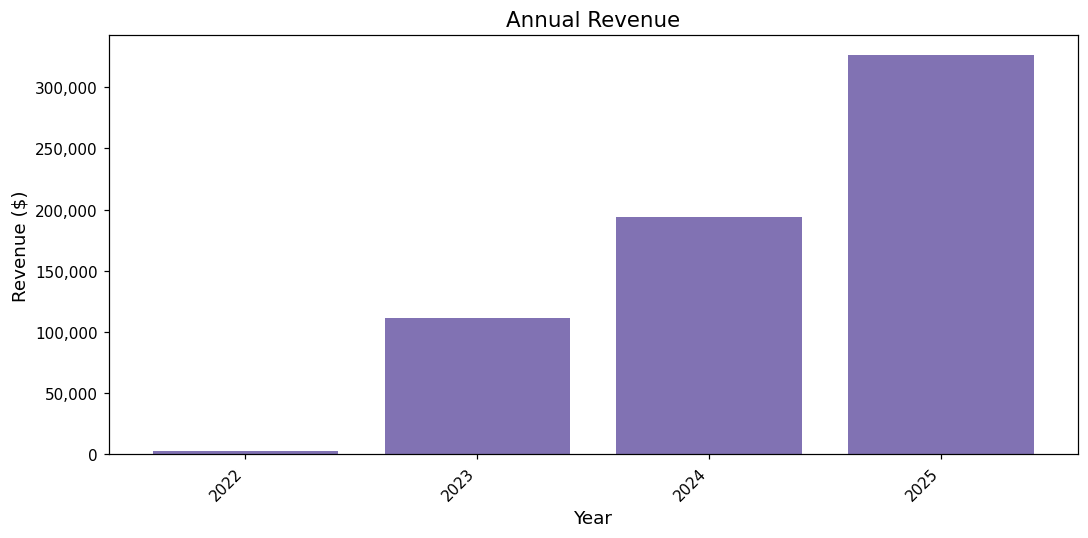

In [18]:
bar_chart(df, "year", "revenue",
          "Annual Revenue",
          xlabel="Year", ylabel="Revenue ($)",
          color=PALETTE[4])
plt.show()

### I6 — Orders per Day of Week
Are there patterns in which day orders are placed?

In [19]:
sql = """
SELECT DAYNAME(order_date)  AS day_name,
       DAYOFWEEK(order_date) AS day_num,
       COUNT(*)              AS orders
FROM   orders
GROUP  BY day_name, day_num
ORDER  BY day_num;
"""
df = con.execute(sql).df()
df

,day_name,day_num,orders
0,Sunday,0,1099
1,Monday,1,1044
2,Tuesday,2,1058
3,Wednesday,3,1052
4,Thursday,4,1125
5,Friday,5,1059
6,Saturday,6,1063


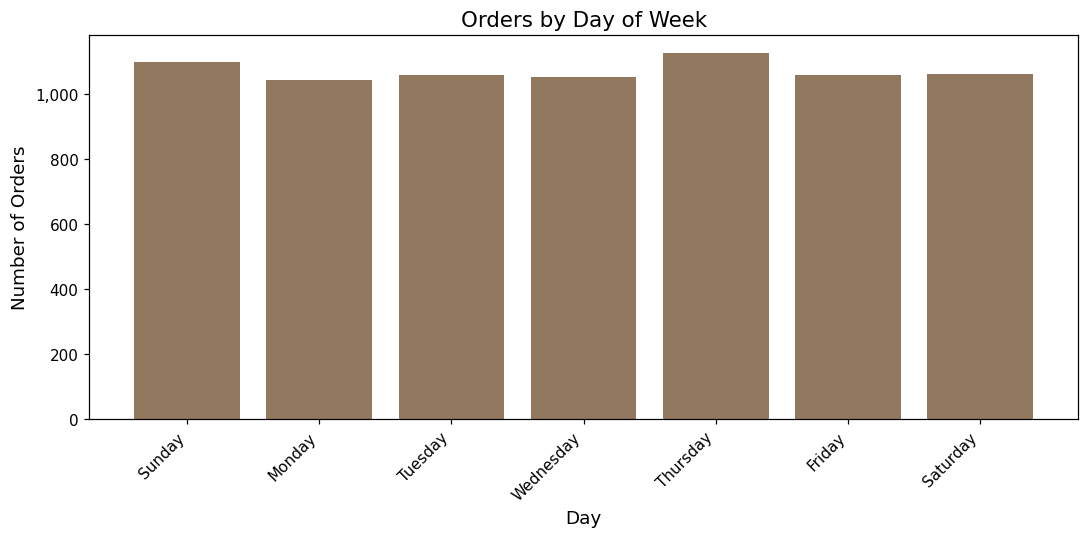

In [20]:
bar_chart(df, "day_name", "orders",
          "Orders by Day of Week",
          xlabel="Day", ylabel="Number of Orders",
          color=PALETTE[5])
plt.show()

### I7 — Average Order Value by Genre
Which genres command higher order values?

In [21]:
sql = """
SELECT b.genre,
       ROUND(AVG(o.total_amount), 2) AS avg_order_value,
       ROUND(AVG(o.quantity), 1)     AS avg_qty
FROM   orders o
JOIN   books b ON o.book_id = b.book_id
GROUP  BY b.genre
ORDER  BY avg_order_value DESC;
"""
df = con.execute(sql).df()
df

,genre,avg_order_value,avg_qty
0,Fiction,89.04,3.1
1,Biography,87.26,3.1
2,Romance,86.94,3.1
3,Non-Fiction,84.83,2.9
4,Science Fiction,82.29,3.0
5,Fantasy,81.60,3.1
6,Mystery,81.40,3.1


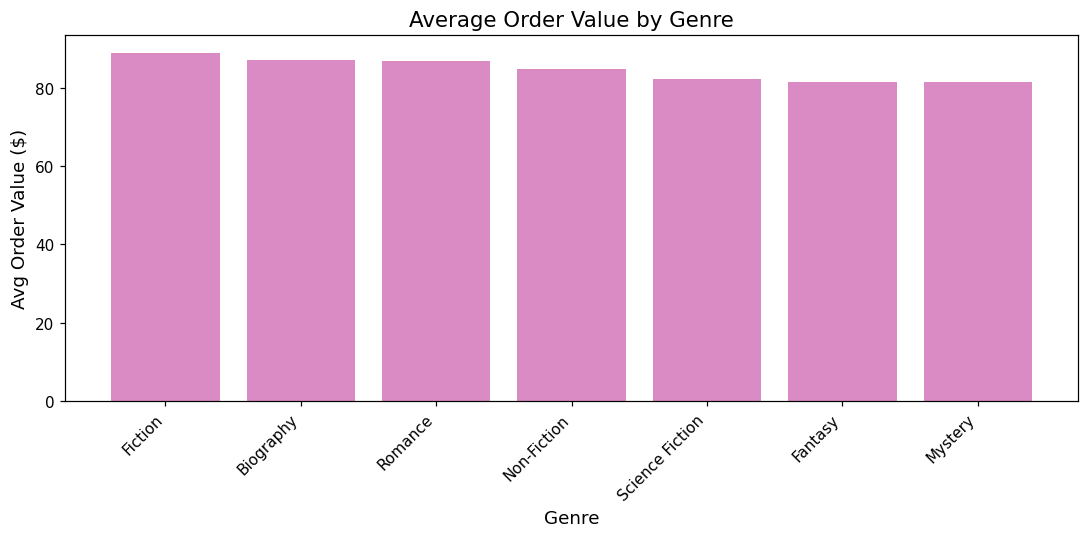

In [22]:
bar_chart(df, "genre", "avg_order_value",
          "Average Order Value by Genre",
          xlabel="Genre", ylabel="Avg Order Value ($)",
          color=PALETTE[6])
plt.show()

### I8 — Books That Have Never Been Ordered
Are there books sitting unsold in inventory?

In [23]:
sql = """
SELECT b.book_id, b.title, b.author, b.genre, b.price, b.stock
FROM   books b
LEFT   JOIN orders o ON b.book_id = o.book_id
WHERE  o.order_id IS NULL
ORDER  BY b.stock DESC;
"""
df = con.execute(sql).df()
print(f"Books never ordered: {len(df)}")
df.head(10)

Books never ordered: 3


,book_id,title,author,genre,price,stock
0,999,Innovative AI,Matthew Minachi,Science Fiction,38.21,7
1,888,The Art of Python,Brandon Taylor,Mystery,23.65,5
2,777,Total Sports,Andrea Smith,Science Fiction,55.46,2


### I9 — Customer Order Frequency Distribution
How many orders do most customers place?

In [24]:
sql = """
SELECT order_count, COUNT(*) AS num_customers
FROM (
    SELECT customer_id, COUNT(*) AS order_count
    FROM   orders
    GROUP  BY customer_id
)
GROUP BY order_count
ORDER BY order_count;
"""
df = con.execute(sql).df()
df.head(15)

,order_count,num_customers
0,2,8
1,3,21
2,4,40
3,5,60
4,6,68
5,7,59
6,8,61
7,9,41
8,10,27
9,11,19


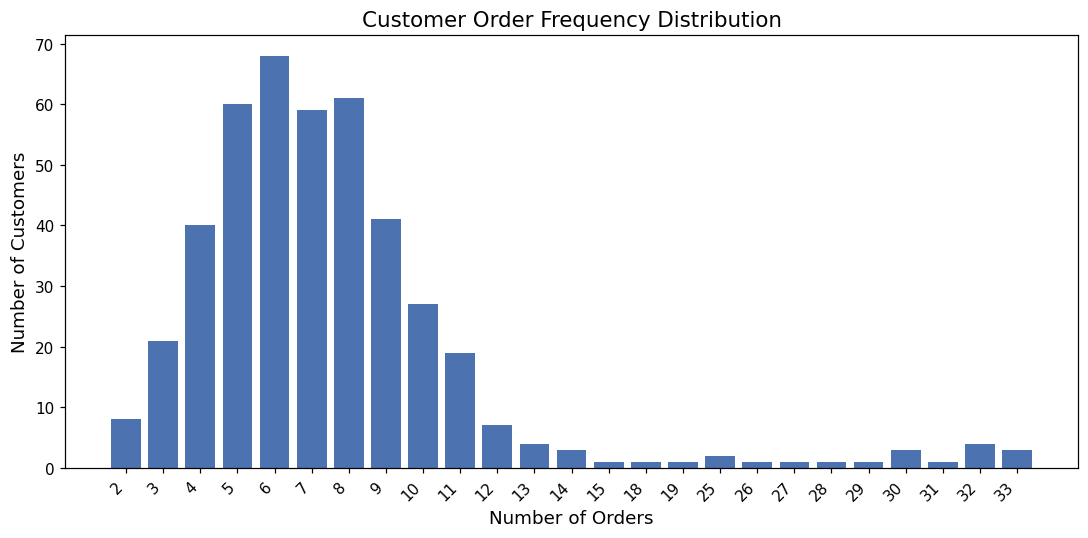

In [25]:
bar_chart(df.head(25), "order_count", "num_customers",
          "Customer Order Frequency Distribution",
          xlabel="Number of Orders", ylabel="Number of Customers",
          color=PALETTE[0])
plt.show()

### I10 — Quarterly Revenue by Year
Revenue broken down by quarter and year.

In [26]:
sql = """
SELECT EXTRACT(YEAR FROM order_date)    AS year,
       EXTRACT(QUARTER FROM order_date) AS quarter,
       ROUND(SUM(total_amount), 2)      AS revenue
FROM   orders
GROUP  BY year, quarter
ORDER  BY year, quarter;
"""
df = con.execute(sql).df()
df["label"] = df["year"].astype(int).astype(str) + "-Q" + df["quarter"].astype(int).astype(str)
df

,year,quarter,revenue,label
0,2022,4,2513.36,2022-Q4
1,2023,1,19609.50,2023-Q1
2,2023,2,26956.47,2023-Q2
3,2023,3,26026.92,2023-Q3
4,2023,4,39143.80,2023-Q4
5,2024,1,40377.18,2024-Q1
6,2024,2,34647.70,2024-Q2
7,2024,3,43169.21,2024-Q3
8,2024,4,75274.09,2024-Q4
9,2025,1,52485.38,2025-Q1


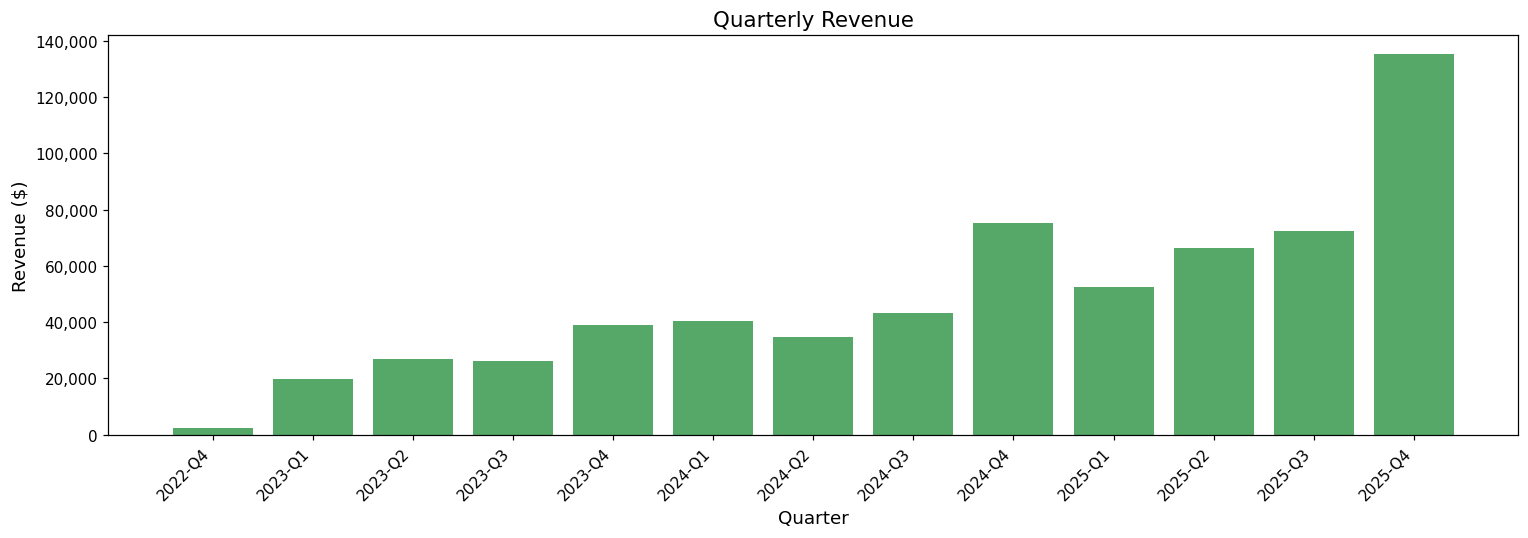

In [27]:
bar_chart(df, "label", "revenue",
          "Quarterly Revenue",
          xlabel="Quarter", ylabel="Revenue ($)",
          color=PALETTE[2], figsize=(14, 5))
plt.show()

### I11 — Price Distribution of Books
What does the distribution of book prices look like?

In [28]:
sql = """
SELECT price FROM books;
"""
df = con.execute(sql).df()
df.describe()

,price
count,503.000000
mean,27.437455
std,13.272877
min,5.070000
25%,15.525000
50%,27.320000
75%,38.520000
max,55.460000


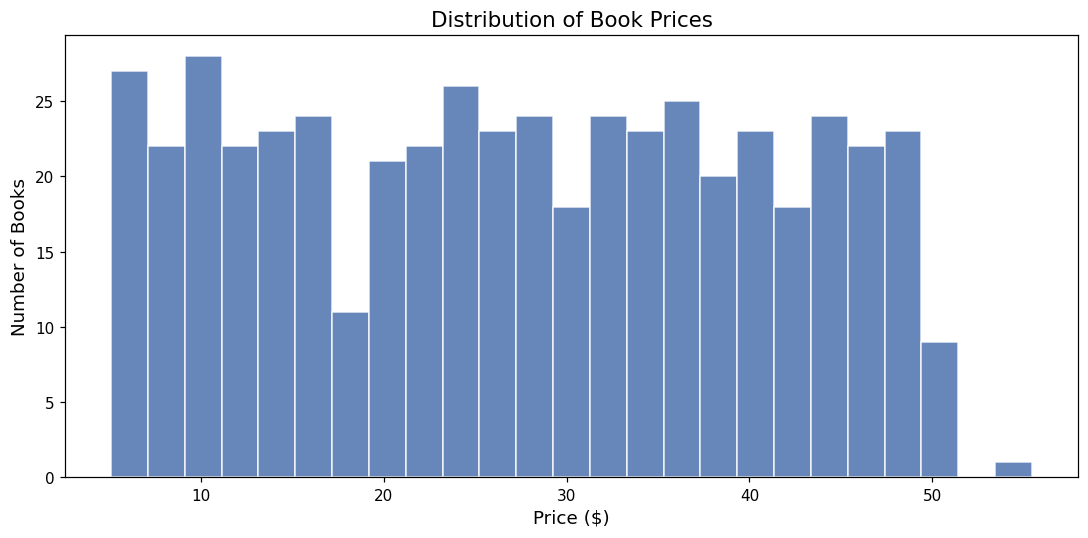

In [29]:
histogram(df["price"], bins=25,
           title="Distribution of Book Prices",
           xlabel="Price ($)", ylabel="Number of Books")
plt.show()

### I12 — Top 10 Authors by Revenue
Which authors bring in the most money?

In [30]:
sql = """
SELECT b.author,
       COUNT(DISTINCT b.book_id)      AS books_in_store,
       SUM(o.quantity)                AS units_sold,
       ROUND(SUM(o.total_amount), 2) AS total_revenue
FROM   orders o
JOIN   books b ON o.book_id = b.book_id
GROUP  BY b.author
ORDER  BY total_revenue DESC
LIMIT  10;
"""
df = con.execute(sql).df()
df

,author,books_in_store,units_sold,total_revenue
0,Joyce Patton,1,92.0,4223.72
1,Thomas Chung,1,86.0,3814.96
2,Andrea Eaton,1,80.0,3723.20
3,Veronica Hebert,1,83.0,3679.39
4,Zachary Hayes,1,71.0,3514.50
5,Samuel Morales,1,82.0,3457.94
6,Craig Smith,1,68.0,3368.04
7,Michelle Edwards,1,76.0,3365.28
8,Anna Roberts,1,73.0,3312.74
9,Daniel Nunez,1,68.0,3222.52


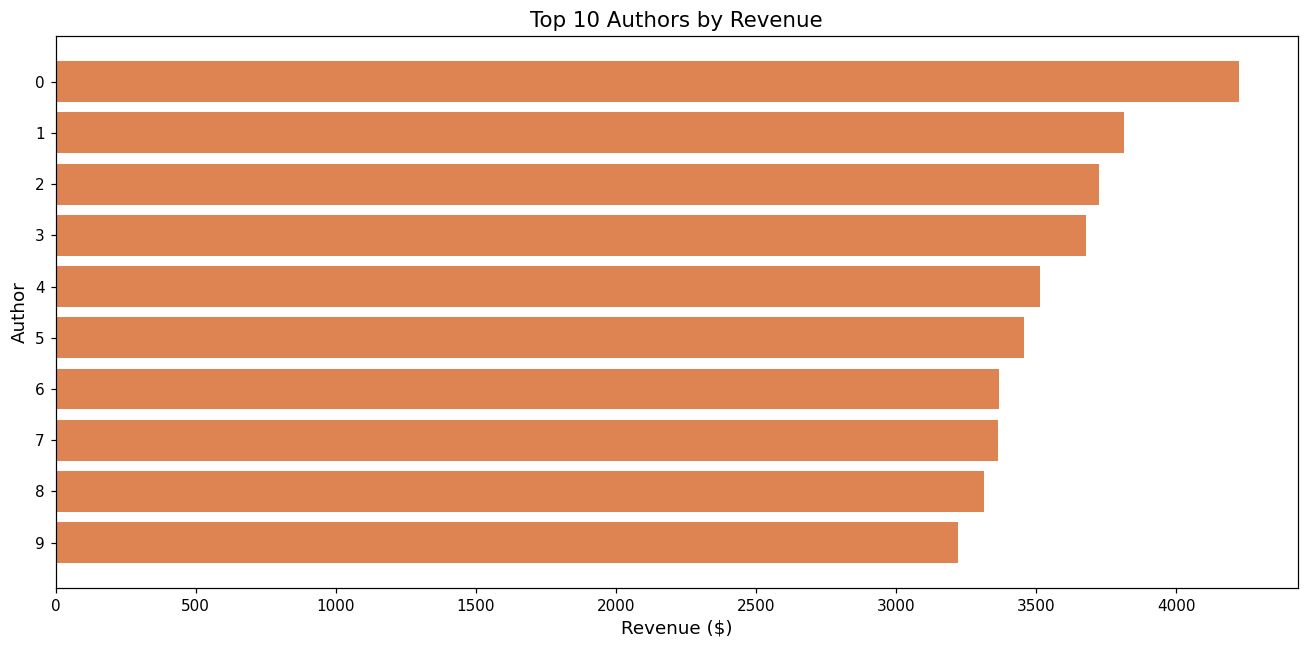

In [31]:
bar_chart(df, "author", "total_revenue",
          "Top 10 Authors by Revenue",
          xlabel="Author", ylabel="Revenue ($)",
          horizontal=True, color=PALETTE[1], figsize=(12, 6))
plt.show()

### I13 — November & December Sales Spike
Do holiday months really outperform the rest?

In [32]:
sql = """
SELECT EXTRACT(MONTH FROM order_date) AS month_num,
       MONTHNAME(order_date)          AS month_name,
       COUNT(*)                       AS orders,
       ROUND(SUM(total_amount), 2)   AS revenue
FROM   orders
GROUP  BY month_num, month_name
ORDER  BY month_num;
"""
df = con.execute(sql).df()
df

,month_num,month_name,orders,revenue
0,1,January,386,34526.10
1,2,February,395,36336.04
2,3,March,487,41609.92
3,4,April,457,40513.67
4,5,May,514,45807.04
5,6,June,506,41491.12
6,7,July,638,51836.59
7,8,August,521,45197.85
8,9,September,516,44401.07
9,10,October,598,48923.25


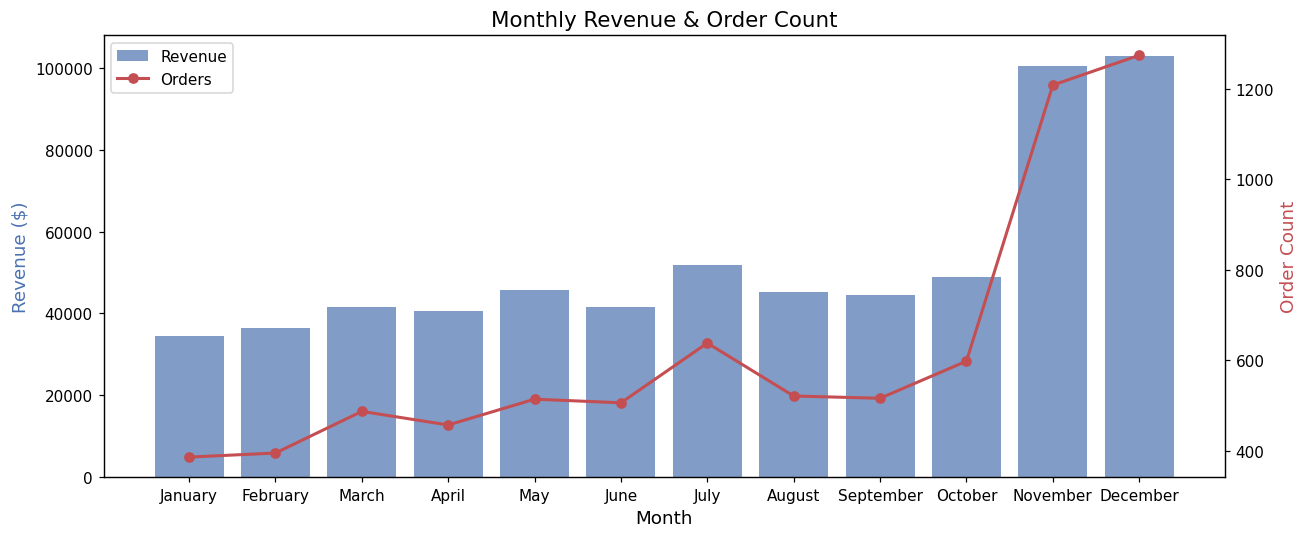

In [33]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(df["month_name"], df["revenue"], color=PALETTE[0], alpha=0.7, label="Revenue")
ax1.set_ylabel("Revenue ($)", color=PALETTE[0])
ax1.set_xlabel("Month")
ax2 = ax1.twinx()
ax2.plot(df["month_name"], df["orders"], color=PALETTE[3], marker="o", linewidth=2, label="Orders")
ax2.set_ylabel("Order Count", color=PALETTE[3])
ax1.set_title("Monthly Revenue & Order Count")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### I14 — Revenue by Country (Top 15)
Which countries generate the most bookstore revenue?

In [34]:
sql = """
SELECT c.country,
       COUNT(DISTINCT c.customer_id)  AS customers,
       ROUND(SUM(o.total_amount), 2) AS revenue
FROM   orders o
JOIN   customers c ON o.customer_id = c.customer_id
GROUP  BY c.country
ORDER  BY revenue DESC
LIMIT  15;
"""
df = con.execute(sql).df()
df

,country,customers,revenue
0,Micronesia,6,15688.88
1,Netherlands Antilles,3,13972.59
2,Senegal,5,12669.58
3,Sri Lanka,4,12340.43
4,Congo,4,12178.20
5,Iran,4,11947.52
6,Myanmar,4,11303.12
7,Nigeria,1,11299.67
8,United Arab Emirates,2,10787.37
9,Ireland,1,10715.71


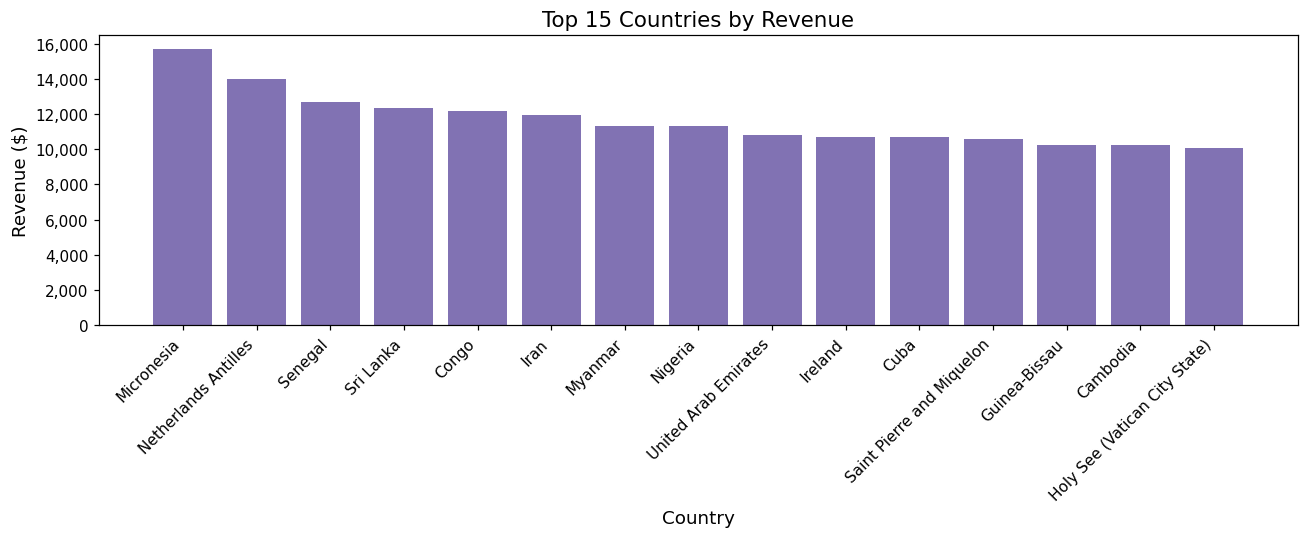

In [35]:
bar_chart(df, "country", "revenue",
          "Top 15 Countries by Revenue",
          xlabel="Country", ylabel="Revenue ($)",
          color=PALETTE[4], figsize=(12, 5))
plt.show()

### I15 — Stock vs. Sales Comparison
Are high-stock books selling, or just sitting on shelves?

In [36]:
sql = """
SELECT b.book_id,
       b.title,
       b.stock,
       COALESCE(SUM(o.quantity), 0) AS total_sold
FROM   books b
LEFT   JOIN orders o ON b.book_id = o.book_id
GROUP  BY b.book_id, b.title, b.stock
ORDER  BY b.stock DESC
LIMIT  30;
"""
df = con.execute(sql).df()
df.head(10)

,book_id,title,stock,total_sold
0,369,Diverse responsive focus group,100,55.0
1,29,Quality-focused multi-tasking challenge,100,64.0
2,254,Team-oriented bandwidth-monitored project,100,44.0
3,173,Ergonomic foreground Graphic Interface,100,22.0
4,32,Synergistic dedicated concept,100,49.0
5,475,Stand-alone zero administration emulation,100,41.0
6,1,Configurable modular throughput,100,27.0
7,193,Customer-focused tertiary methodology,100,41.0
8,365,Synchronized impactful synergy,99,55.0
9,13,Adaptive 5thgeneration orchestration,99,48.0


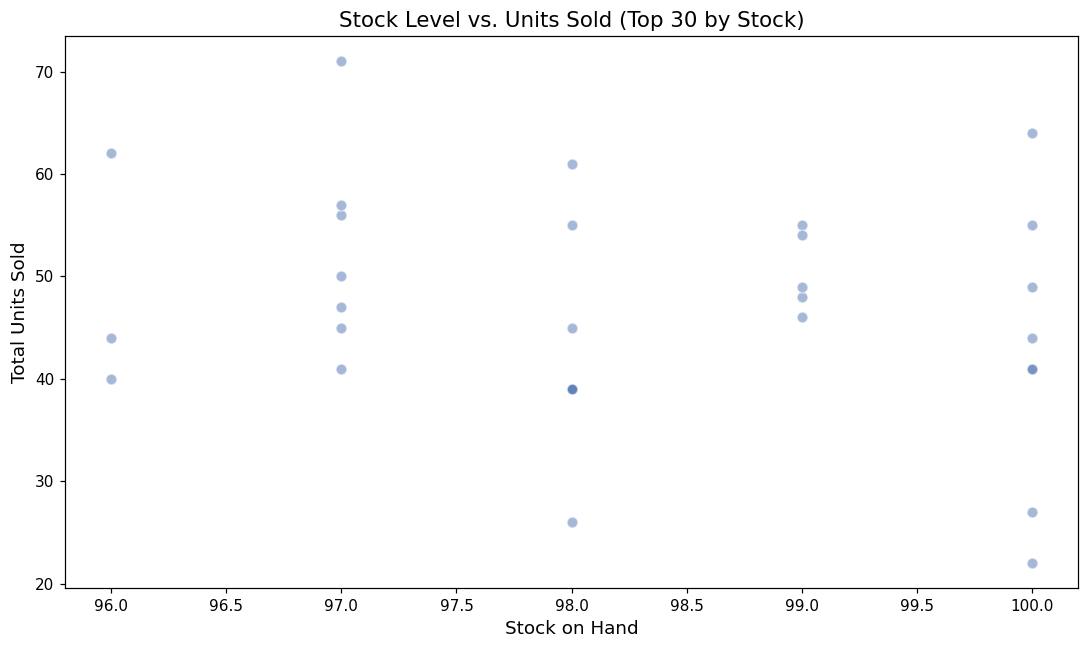

In [37]:
scatter_plot(df, "stock", "total_sold",
             "Stock Level vs. Units Sold (Top 30 by Stock)",
             xlabel="Stock on Hand", ylabel="Total Units Sold")
plt.show()

---
## Advanced Queries

### A1 — Year-over-Year Revenue Growth Rate
Calculate the percentage change in revenue from one year to the next using a window function.

In [38]:
sql = """
WITH yearly AS (
    SELECT EXTRACT(YEAR FROM order_date)  AS year,
           ROUND(SUM(total_amount), 2)    AS revenue
    FROM   orders
    GROUP  BY year
)
SELECT year,
       revenue,
       LAG(revenue) OVER (ORDER BY year)                         AS prev_year_rev,
       ROUND(
           (revenue - LAG(revenue) OVER (ORDER BY year))
           / LAG(revenue) OVER (ORDER BY year) * 100, 1
       )                                                          AS yoy_growth_pct
FROM   yearly
ORDER  BY year;
"""
df = con.execute(sql).df()
df

,year,revenue,prev_year_rev,yoy_growth_pct
0,2022,2513.36,NaN,NaN
1,2023,111736.69,2513.36,4345.7
2,2024,193468.18,111736.69,73.1
3,2025,326140.96,193468.18,68.6


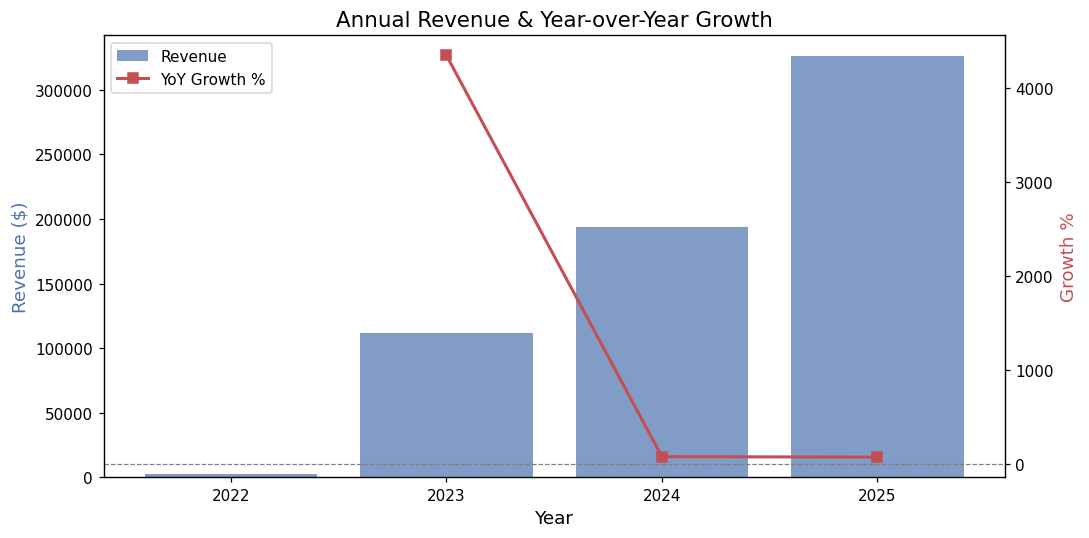

In [39]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(df["year"].astype(int).astype(str), df["revenue"], color=PALETTE[0], alpha=0.7, label="Revenue")
ax1.set_ylabel("Revenue ($)", color=PALETTE[0])
ax1.set_xlabel("Year")
ax2 = ax1.twinx()
growth = df.dropna(subset=["yoy_growth_pct"])
ax2.plot(growth["year"].astype(int).astype(str), growth["yoy_growth_pct"],
         color=PALETTE[3], marker="s", linewidth=2, label="YoY Growth %")
ax2.set_ylabel("Growth %", color=PALETTE[3])
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax1.set_title("Annual Revenue & Year-over-Year Growth")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

### A2 — Customer RFM Segmentation (Recency, Frequency, Monetary)
Classify customers into segments using quintile-based RFM scoring.

In [40]:
sql = """
WITH rfm AS (
    SELECT c.customer_id,
           c.name,
           DATEDIFF('day', MAX(o.order_date), (SELECT MAX(order_date) FROM orders)) AS recency,
           COUNT(o.order_id)              AS frequency,
           ROUND(SUM(o.total_amount), 2) AS monetary
    FROM   customers c
    JOIN   orders o ON c.customer_id = o.customer_id
    GROUP  BY c.customer_id, c.name
),
scored AS (
    SELECT *,
           NTILE(5) OVER (ORDER BY recency DESC)  AS r_score,
           NTILE(5) OVER (ORDER BY frequency)      AS f_score,
           NTILE(5) OVER (ORDER BY monetary)       AS m_score
    FROM rfm
)
SELECT *,
       r_score + f_score + m_score AS rfm_total,
       CASE
           WHEN r_score + f_score + m_score >= 13 THEN 'Champions'
           WHEN r_score + f_score + m_score >= 10 THEN 'Loyal'
           WHEN r_score + f_score + m_score >= 7  THEN 'At Risk'
           ELSE 'Lost'
       END AS segment
FROM scored
ORDER BY rfm_total DESC;
"""
df = con.execute(sql).df()
print(f"Total customers scored: {len(df)}")
df.head(10)

Total customers scored: 500


,customer_id,name,recency,frequency,monetary,r_score,f_score,m_score,rfm_total,segment
0,311,Victoria Taylor,0,36,2484.00,5,5,5,15,Champions
1,163,Robert Clark,5,35,3269.07,5,5,5,15,Champions
2,303,Jose Lee,0,125,10910.73,5,5,5,15,Champions
3,45,Jennifer Fowler,0,135,10715.71,5,5,5,15,Champions
4,141,Ryan Hernandez,0,119,10565.33,5,5,5,15,Champions
5,378,Anthony Kane,1,124,10465.80,5,5,5,15,Champions
6,58,Michael Young,0,127,10343.26,5,5,5,15,Champions
7,347,Peter Greene,0,146,10256.92,5,5,5,15,Champions
8,457,Kim Turner,1,121,10243.01,5,5,5,15,Champions
9,126,Bonnie Mcdonald,2,123,10081.90,5,5,5,15,Champions


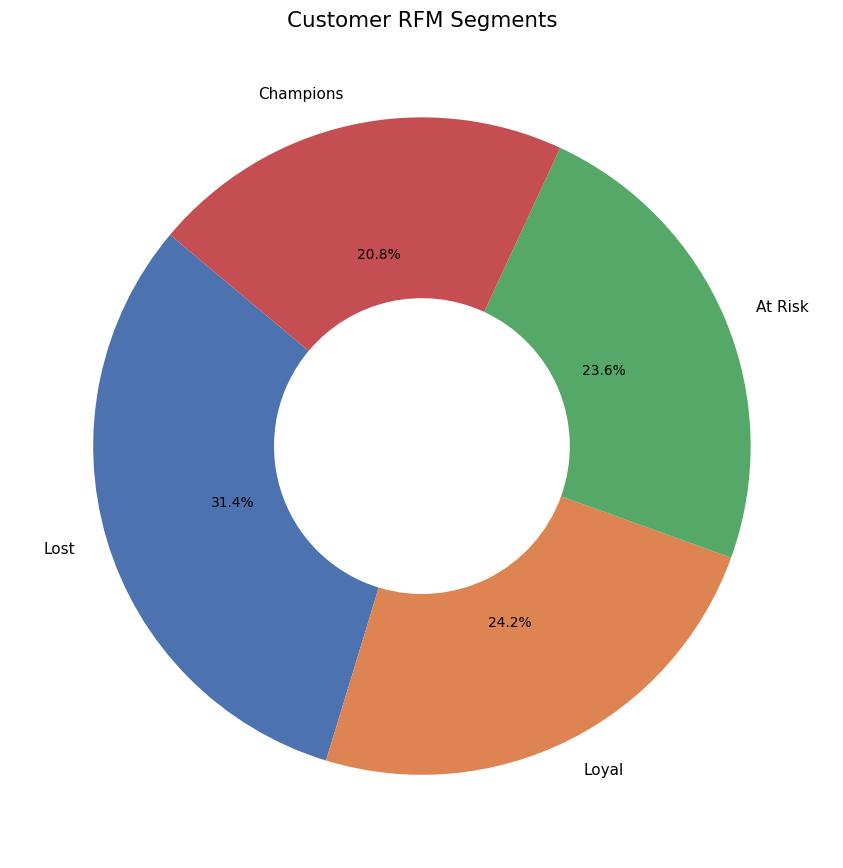

In [41]:
seg = df["segment"].value_counts().reset_index()
seg.columns = ["segment", "count"]
pie_chart(seg, "segment", "count",
          "Customer RFM Segments")
plt.show()

### A3 — Cumulative Revenue with Running Total
Show daily revenue alongside a running cumulative total using window functions.

In [42]:
sql = """
WITH daily AS (
    SELECT order_date,
           ROUND(SUM(total_amount), 2) AS daily_rev
    FROM   orders
    WHERE  EXTRACT(YEAR FROM order_date) = 2025
    GROUP  BY order_date
)
SELECT order_date,
       daily_rev,
       ROUND(SUM(daily_rev) OVER (ORDER BY order_date), 2) AS cumulative_rev
FROM   daily
ORDER  BY order_date;
"""
df = con.execute(sql).df()
print(f"Days in 2025 with orders: {len(df)}")
df.tail(10)

Days in 2025 with orders: 365


,order_date,daily_rev,cumulative_rev
355,2025-12-22,2315.87,309909.53
356,2025-12-23,1188.94,311098.47
357,2025-12-24,2761.07,313859.54
358,2025-12-25,745.13,314604.67
359,2025-12-26,1845.94,316450.61
360,2025-12-27,1961.73,318412.34
361,2025-12-28,1193.05,319605.39
362,2025-12-29,2905.15,322510.54
363,2025-12-30,2145.75,324656.29
364,2025-12-31,1484.67,326140.96


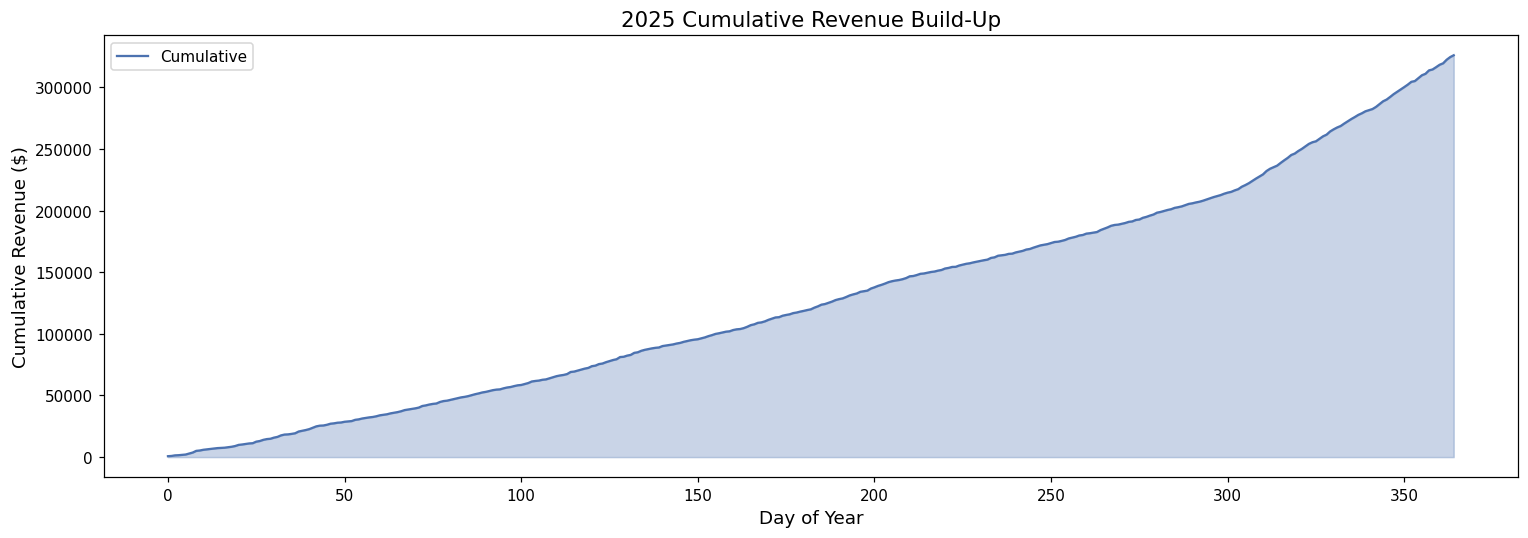

In [43]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.fill_between(range(len(df)), df["cumulative_rev"], alpha=0.3, color=PALETTE[0])
ax1.plot(range(len(df)), df["cumulative_rev"], color=PALETTE[0], linewidth=1.5, label="Cumulative")
ax1.set_xlabel("Day of Year")
ax1.set_ylabel("Cumulative Revenue ($)")
ax1.set_title("2025 Cumulative Revenue Build-Up")
ax1.legend()
plt.tight_layout()
plt.show()

### A4 — Genre Revenue Heatmap by Year and Genre
Pivot revenue data into a year x genre matrix and visualize as a heatmap.

In [44]:
sql = """
SELECT EXTRACT(YEAR FROM o.order_date) AS year,
       b.genre,
       ROUND(SUM(o.total_amount), 2)  AS revenue
FROM   orders o
JOIN   books b ON o.book_id = b.book_id
GROUP  BY year, b.genre
ORDER  BY year, b.genre;
"""
df = con.execute(sql).df()
pivot = df.pivot(index="genre", columns="year", values="revenue").fillna(0)
pivot.columns = pivot.columns.astype(int).astype(str)
pivot

year,2022,2023,2024,2025
genre,,,,
Biography,374.48,18018.58,21313.68,45811.63
Fantasy,484.64,14491.63,29139.28,44259.55
Fiction,371.92,12306.11,23372.51,41684.05
Mystery,142.38,19010.35,27494.82,49809.01
Non-Fiction,347.19,15522.11,28850.75,43844.91
Romance,792.75,15249.57,31620.72,47097.92
Science Fiction,0.00,17138.34,31676.42,53633.89


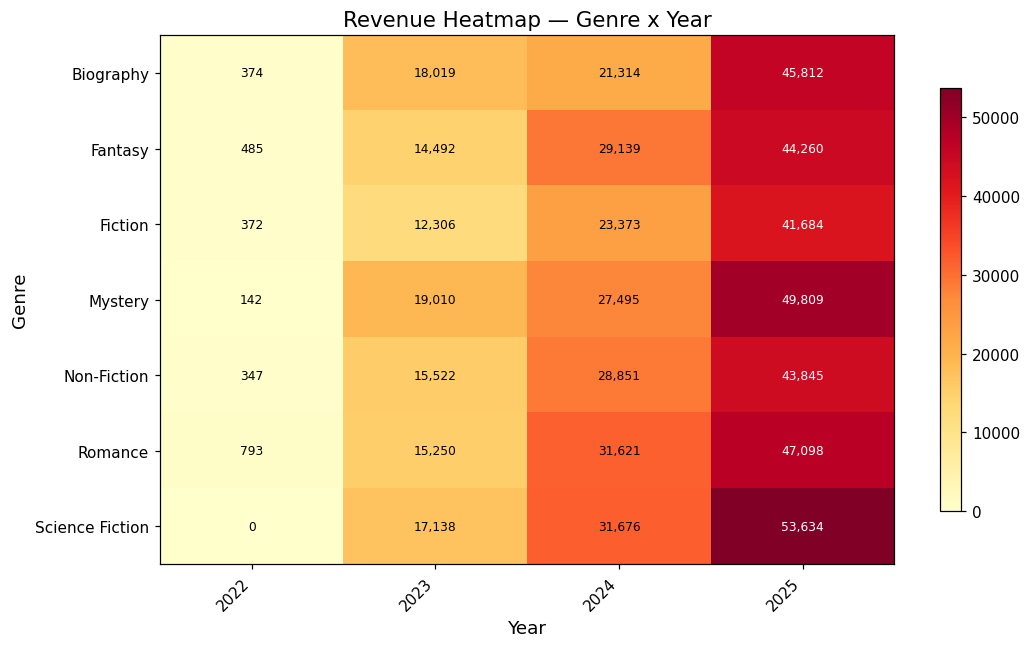

In [45]:
heatmap(pivot,
        "Revenue Heatmap — Genre x Year",
        xlabel="Year", ylabel="Genre", fmt=",.0f",
        figsize=(10, 6))
plt.show()

### A5 — Pareto Analysis: Top 20% Customers Driving Revenue
Verify the 80/20 rule — do 20% of customers generate ~80% of revenue?

In [46]:
sql = """
WITH cust_rev AS (
    SELECT customer_id,
           ROUND(SUM(total_amount), 2) AS revenue
    FROM   orders
    GROUP  BY customer_id
)
SELECT customer_id,
       revenue,
       ROUND(SUM(revenue) OVER (ORDER BY revenue DESC), 2) AS cum_revenue,
       ROUND(SUM(revenue) OVER (), 2)                      AS grand_total,
       ROUND(SUM(revenue) OVER (ORDER BY revenue DESC)
             / SUM(revenue) OVER () * 100, 2)              AS cum_pct,
       ROW_NUMBER() OVER (ORDER BY revenue DESC)            AS rank
FROM   cust_rev
ORDER  BY revenue DESC;
"""
df = con.execute(sql).df()
top_20_pct = int(len(df) * 0.2)
rev_by_top20 = df.head(top_20_pct)["revenue"].sum()
total = df["revenue"].sum()
print(f"Total customers: {len(df)}")
print(f"Top 20% ({top_20_pct} customers) generate ${rev_by_top20:,.2f} "
      f"= {rev_by_top20/total*100:.1f}% of total ${total:,.2f}")
df.head(10)

Total customers: 500
Top 20% (100 customers) generate $405,483.12 = 64.0% of total $633,859.19


,customer_id,revenue,cum_revenue,grand_total,cum_pct,rank
0,115,11457.05,11457.05,633859.19,1.81,1
1,13,11299.67,22756.72,633859.19,3.59,2
2,303,10910.73,33667.45,633859.19,5.31,3
3,45,10715.71,44383.16,633859.19,7.00,4
4,141,10565.33,54948.49,633859.19,8.67,5
5,378,10465.80,65414.29,633859.19,10.32,6
6,58,10343.26,75757.55,633859.19,11.95,7
7,347,10256.92,86014.47,633859.19,13.57,8
8,457,10243.01,96257.48,633859.19,15.19,9
9,126,10081.90,106339.38,633859.19,16.78,10


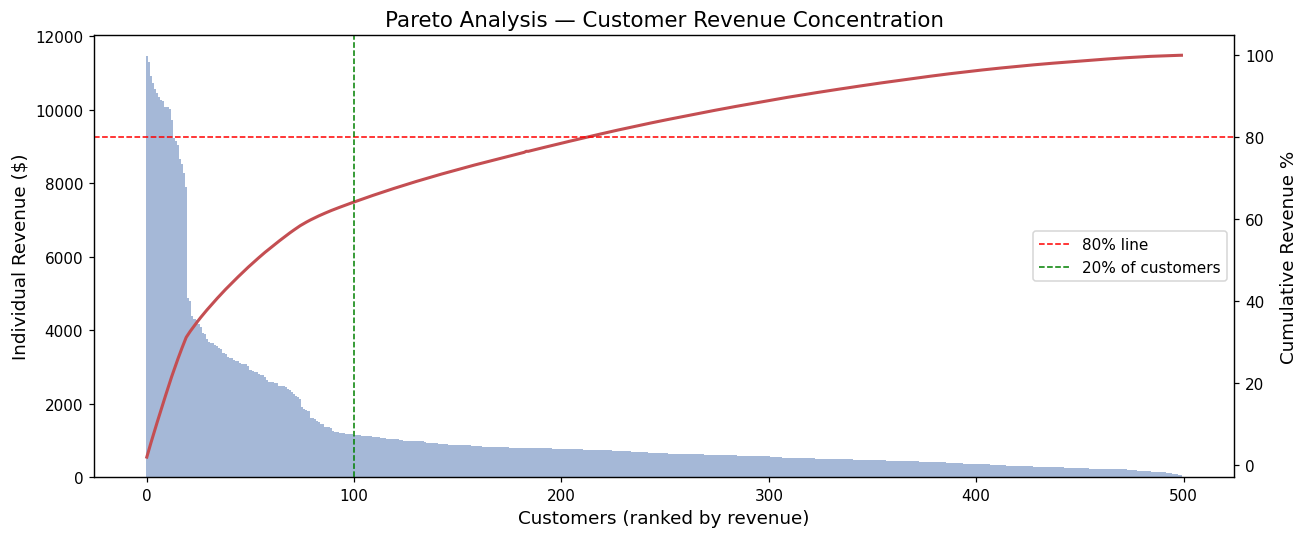

In [47]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(df)), df["revenue"], color=PALETTE[0], alpha=0.5, width=1.0)
ax2 = ax.twinx()
ax2.plot(range(len(df)), df["cum_pct"], color=PALETTE[3], linewidth=2)
ax2.axhline(80, color="red", linestyle="--", linewidth=1, label="80% line")
ax2.axvline(int(len(df)*0.2), color="green", linestyle="--", linewidth=1, label="20% of customers")
ax.set_xlabel("Customers (ranked by revenue)")
ax.set_ylabel("Individual Revenue ($)")
ax2.set_ylabel("Cumulative Revenue %")
ax.set_title("Pareto Analysis — Customer Revenue Concentration")
ax2.legend(loc="center right")
plt.tight_layout()
plt.show()

### A6 — Customers Who Have Never Purchased Any Books
Identify customers with zero orders using a `LEFT JOIN` / `IS NULL` anti-join pattern.
These are prospects for re-engagement campaigns.

In [48]:
sql = """
SELECT c.customer_id,
       c.name,
       c.email,
       c.city,
       c.country
FROM   customers c
LEFT   JOIN orders o ON c.customer_id = o.customer_id
WHERE  o.order_id IS NULL
ORDER  BY c.customer_id;
"""
df = con.execute(sql).df()
print(f"Customers who never purchased: {len(df)} out of {con.execute('SELECT COUNT(*) FROM customers').fetchone()[0]}")
df

Customers who never purchased: 4 out of 504


,customer_id,name,email,city,country
0,1001,Alex Johnson,alex100@manning.net,Sunnyvale,Israel
1,1020,Betty Payne,betty789@hotmail.com,London,United Kingdom
2,3400,Michelle Stars,mstars@howard.org,South Eric,Armenia
3,3405,Robert Harrison,robertharrison@gmail.com,Lake Sarahside,Finland


### A7 — Books That No One Has Ordered
Identify books with zero purchases using a `LEFT JOIN` / `IS NULL` anti-join.
These titles may need promotion, discounting, or removal from inventory.

In [49]:
sql = """
SELECT b.book_id,
       b.title,
       b.author,
       b.genre,
       b.published_year,
       b.price,
       b.stock
FROM   books b
LEFT   JOIN orders o ON b.book_id = o.book_id
WHERE  o.order_id IS NULL
ORDER  BY b.price DESC;
"""
df = con.execute(sql).df()
print(f"Books never ordered: {len(df)} out of {con.execute('SELECT COUNT(*) FROM books').fetchone()[0]}")
df

Books never ordered: 3 out of 503


,book_id,title,author,genre,published_year,price,stock
0,777,Total Sports,Andrea Smith,Science Fiction,2013,55.46,2
1,999,Innovative AI,Matthew Minachi,Science Fiction,2019,38.21,7
2,888,The Art of Python,Brandon Taylor,Mystery,1999,23.65,5


---
## Cleanup

In [50]:
con.close()
print("Connection closed.")

Connection closed.
